In [ ]:
# 1. Install the Kaggle library
!pip install kaggle

# 2. Set up the Kaggle API key
from google.colab import files
import os

# Upload your kaggle.json file
if not os.path.exists("/root/.kaggle/kaggle.json"):
    uploaded = files.upload()
    for fn in uploaded.keys():
        !mkdir -p ~/.kaggle
        !mv $fn ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json
    print("Kaggle API key uploaded.")
else:
    print("Kaggle API key already exists.")

# 3. Download the corrected dataset

!kaggle datasets download -d nolasthitnotomorrow/radioml2016-deepsigcom

# 4. Unzip the dataset
!unzip -o nolasthitnotomorrow/radioml2016-deepsigcom.zip

Saving kaggle.json to kaggle.json
Kaggle API key uploaded.
Dataset URL: https://www.kaggle.com/datasets/nolasthitnotomorrow/radioml2016-deepsigcom
License(s): CC-BY-NC-SA-4.0
 54% 152M/279M [00:00<00:00, 1.59GB/s]
100% 279M/279M [00:00<00:00, 876MB/s] 
unzip:  cannot find or open nolasthitnotomorrow/radioml2016-deepsigcom.zip, nolasthitnotomorrow/radioml2016-deepsigcom.zip.zip or nolasthitnotomorrow/radioml2016-deepsigcom.zip.ZIP.


In [ ]:
# Check the exact filename
!ls -lh


total 280M
-rw-r--r-- 1 root root 280M Jul 24  2019 radioml2016-deepsigcom.zip
drwxr-xr-x 1 root root 4.0K Feb  6 14:31 sample_data


In [ ]:
!unzip -o "radioml2016-deepsigcom.zip" -d "./radioml2016"


Archive:  radioml2016-deepsigcom.zip
  inflating: ./radioml2016/RML2016.10a_dict.pkl  


In [ ]:

import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Define the correct path from your screenshot
# The file is inside the 'radioml2016' directory
data_path = './radioml2016/RML2016.10a_dict.pkl'

# 2. Load the dataset with 'latin1' encoding to fix the error
print(f"Loading dataset from: {data_path}...")
with open(data_path, 'rb') as f:
    # This is the fix for the UnicodeDecodeError
    u = pickle._Unpickler(f)
    u.encoding = 'latin1'
    data = u.load()

print("Dataset loaded successfully!")
print(f"Sample key: {list(data.keys())[0]}")

# 3. Extract data, labels, and SNR
X = [] # To store I/Q samples
Y_labels = [] # To store modulation type (string)
snrs = [] # To store SNR values (int)
mods = [] # To store all modulation types (for later)

for mod, snr_val in data.keys():
    # Append all 1000 samples for this (mod, snr) pair
    X.append(data[(mod, snr_val)])

    # Append 1000 labels and snrs
    for _ in range(data[(mod, snr_val)].shape[0]):
        Y_labels.append(mod)
        snrs.append(snr_val)

    if mod not in mods:
        mods.append(mod)

# Convert lists to NumPy arrays
X = np.vstack(X)
snrs = np.array(snrs)
Y_labels = np.array(Y_labels)

print(f"\nTotal X shape: {X.shape}")
print(f"Total Y_labels shape: {Y_labels.shape}")
print(f"Modulation classes: {mods}")

# 4. One-hot encode the labels
# Use LabelEncoder to turn string labels into integers
encoder = LabelEncoder()
Y_int = encoder.fit_transform(Y_labels)

# Use to_categorical to one-hot encode the integers
Y = to_categorical(Y_int)

print(f"\nShape of one-hot encoded Y: {Y.shape}")



Loading dataset from: ./radioml2016/RML2016.10a_dict.pkl...
Dataset loaded successfully!
Sample key: ('QPSK', 2)

Total X shape: (220000, 2, 128)
Total Y_labels shape: (220000,)
Modulation classes: ['QPSK', 'PAM4', 'AM-DSB', 'GFSK', 'QAM64', 'AM-SSB', '8PSK', 'QAM16', 'WBFM', 'CPFSK', 'BPSK']

Shape of one-hot encoded Y: (220000, 11)


In [ ]:
# Original shape: (220000, 2, 128) -> (samples, channels, timesteps)
print(f"Original X shape: {X.shape}")

# We want: (220000, 128, 2) -> (samples, timesteps, features)
# We can use np.transpose to swap axes 1 and 2
X = np.transpose(X, (0, 2, 1))

print(f"Reshaped X for LSTM: {X.shape}")

Original X shape: (220000, 2, 128)
Reshaped X for LSTM: (220000, 128, 2)


In [ ]:
# Split the data into training and test sets (80% train, 20% test)
# We stratify to ensure all classes are represented in both splits
X_train, X_test, Y_train, Y_test, snrs_train, snrs_test = train_test_split(
    X, Y, snrs,
    test_size=0.2,
    random_state=42,
    stratify=Y_int
)

print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (176000, 128, 2)
Y_train shape: (176000, 11)
X_test shape: (44000, 128, 2)
Y_test shape: (44000, 11)


In [ ]:
# --- NEW STEP: Normalize the Data ---


X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
mean = np.mean(X_train_reshaped, axis=0)
std = np.std(X_train_reshaped, axis=0)

print(f"Calculated Mean (I, Q): {mean}")
print(f"Calculated Std Dev (I, Q): {std}")

# 2. We apply this transformation (standardization) to both train and test sets.
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("\nData successfully normalized.")
print(f"New X_train mean (approx): {np.mean(X_train, axis=(0, 1))}")
print(f"New X_train std (approx): {np.std(X_train, axis=(0, 1))}")

Calculated Mean (I, Q): [ 7.0316870e-05 -6.1804743e-04]
Calculated Std Dev (I, Q): [0.00568288 0.0061359 ]

Data successfully normalized.
New X_train mean (approx): [-2.3638588e-06  1.0266944e-04]
New X_train std (approx): [1.0227251 1.0178405]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    LSTM,
    Dense,
    Dropout
)

# Get the number of classes and input shape
n_classes = Y_train.shape[1]
timesteps = X_train.shape[1] # 128
features = X_train.shape[2]  # 2

print(f"Building CLDNN model for {n_classes} classes, with input shape ({timesteps}, {features})")

model = Sequential()

# --- CNN Feature Extractor ---
# Input shape is (128, 2)
model.add(Conv1D(filters=64, kernel_size=5, activation='relu', padding='same',
                 input_shape=(timesteps, features), name="Conv1D_1"))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2, name="MaxPool_1"))

model.add(Conv1D(filters=64, kernel_size=5, activation='relu', padding='same',
                 name="Conv1D_2"))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2, name="MaxPool_2"))
# Output of this block will be a sequence, but shorter (e.g., 128 -> 64 -> 32)
# Shape will be (batch, 32, 64)

# --- LSTM Sequence Learner ---
# Now, feed this sequence of features into the LSTM
model.add(LSTM(units=64, return_sequences=True, name="LSTM_1"))
model.add(Dropout(0.5))

model.add(LSTM(units=64, name="LSTM_2"))
model.add(Dropout(0.5))

# --- Classifier Head ---
model.add(Dense(128, activation='relu', name="Dense_1"))
model.add(Dropout(0.5))

model.add(Dense(n_classes, activation='softmax', name="Output"))

# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Building CLDNN model for 11 classes, with input shape (128, 2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1D_1 (Conv1D)               │ (None, 128, 64)        │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling1D)        │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_2 (Conv1D)               │ (None, 64, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling1D)        │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_1 (LSTM)                   │ (None, 32, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,547 (381.04 KB)

 Trainable params: 97,291 (380.04 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# Set training parameters
EPOCHS = 50
BATCH_SIZE = 1024 # Using a larger batch size is common for this dataset

# Train the model
history = model.fit(
    X_train, Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, Y_test)
)

Epoch 1/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.2742 - loss: 1.9738 - val_accuracy: 0.1413 - val_loss: 3.4650
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.4810 - loss: 1.3258 - val_accuracy: 0.4668 - val_loss: 1.4437
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.4961 - loss: 1.2614 - val_accuracy: 0.5069 - val_loss: 1.2326
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.5038 - loss: 1.2441 - val_accuracy: 0.5102 - val_loss: 1.1964
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.5078 - loss: 1.2299 - val_accuracy: 0.5195 - val_loss: 1.1944
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.5134 - loss: 1.2132 - val_accuracy: 0.5202 - val_loss: 1.1956
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.5117 - loss: 1.2159 - val_accuracy: 0.5238 - val_loss: 1.1960
Epoch 8/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.5167 - loss: 1.2073 - val_acc

Plotting training history...


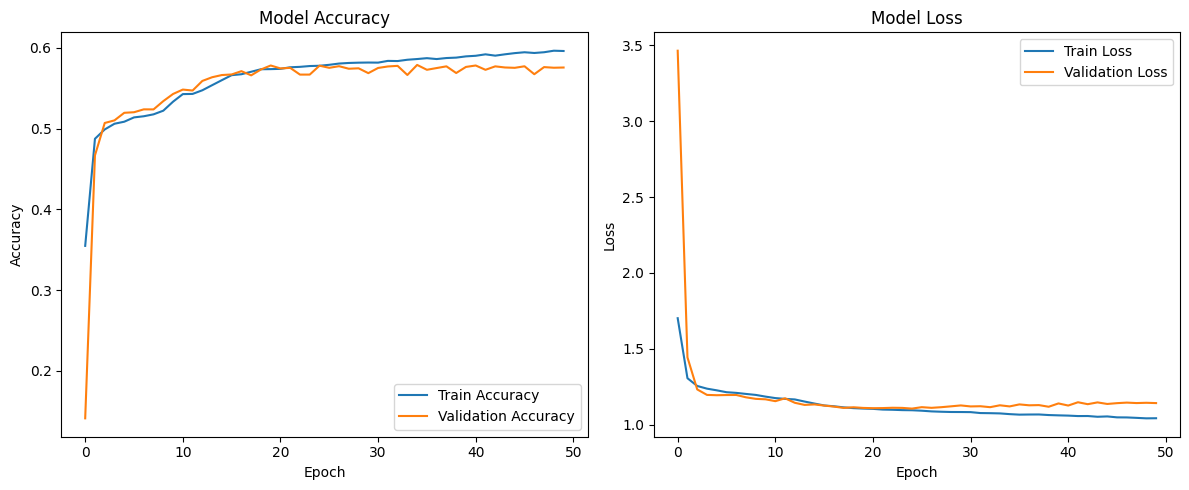

Evaluating overall test accuracy...
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5765 - loss: 1.1323

Overall Test Accuracy: 57.56%
Plotting accuracy vs. SNR...


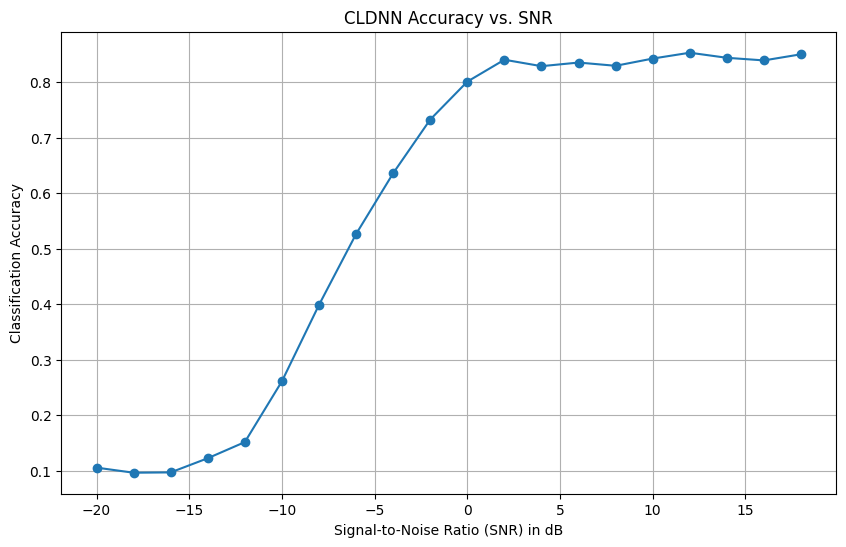

Plotting normalized confusion matrix...
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


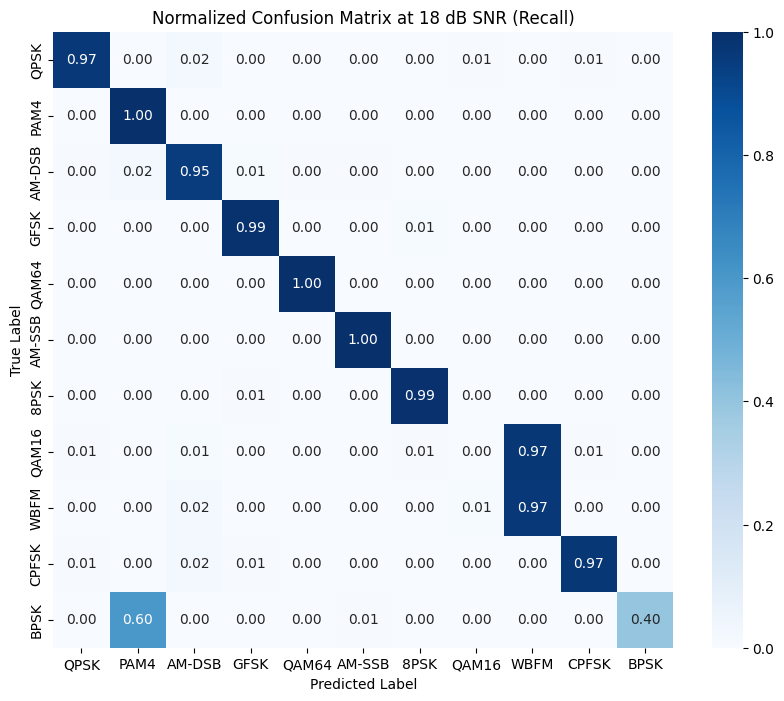

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Plot training & validation accuracy/loss
print("Plotting training history...")
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 2. Evaluate overall test accuracy
print("Evaluating overall test accuracy...")
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"\nOverall Test Accuracy: {accuracy*100:.2f}%")

# 3. Plot Accuracy vs. SNR
print("Plotting accuracy vs. SNR...")
acc_vs_snr = {}
unique_snrs = sorted(np.unique(snrs_test))

for snr in unique_snrs:
    # Get indices of test samples that match the current SNR
    idx = np.where(snrs_test == snr)

    # Select the corresponding X and Y samples
    X_snr = X_test[idx]
    Y_snr = Y_test[idx]

    # Evaluate the model on this subset
    loss, acc = model.evaluate(X_snr, Y_snr, verbose=0)
    acc_vs_snr[snr] = acc

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(list(acc_vs_snr.keys()), list(acc_vs_snr.values()), marker='o')
plt.title('CLDNN Accuracy vs. SNR') # Updated title
plt.xlabel('Signal-to-Noise Ratio (SNR) in dB')
plt.ylabel('Classification Accuracy')
plt.grid(True)
plt.show()

# 4. Plot Confusion Matrix (at a high SNR, e.g., 18 dB)
print("Plotting normalized confusion matrix...")
high_snr_idx = np.where(snrs_test == 18)
X_high_snr = X_test[high_snr_idx]
Y_high_snr = Y_test[high_snr_idx]

# Get predictions
Y_pred = model.predict(X_high_snr)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_high_snr, axis=1)

# --- START OF MODIFICATION ---

# Compute confusion matrix and normalize it by the true labels (rows)
# This shows the proportion of each true class that was predicted as each class
cm = confusion_matrix(Y_true_classes, Y_pred_classes, normalize='true')

# Plot
plt.figure(figsize=(10, 8))

# annot=True displays the values
# fmt='.2f' formats the values as floats with 2 decimal places
# vmin=0.0 and vmax=1.0 lock the color bar to the 0-1 range
sns.heatmap(cm,
            annot=True,
            fmt='.2f',  # <--- CHANGED
            xticklabels=mods,
            yticklabels=mods,
            cmap='Blues',
            vmin=0.0,   # <--- ADDED
            vmax=1.0    # <--- ADDED
           )

plt.title('Normalized Confusion Matrix at 18 dB SNR (Recall)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



In [ ]:
model_filename = 'cldnn_radioml_10a.keras'
model.save(model_filename)

print(f"Model successfully saved as: {model_filename}")

Plotting normalized confusion matrix...
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


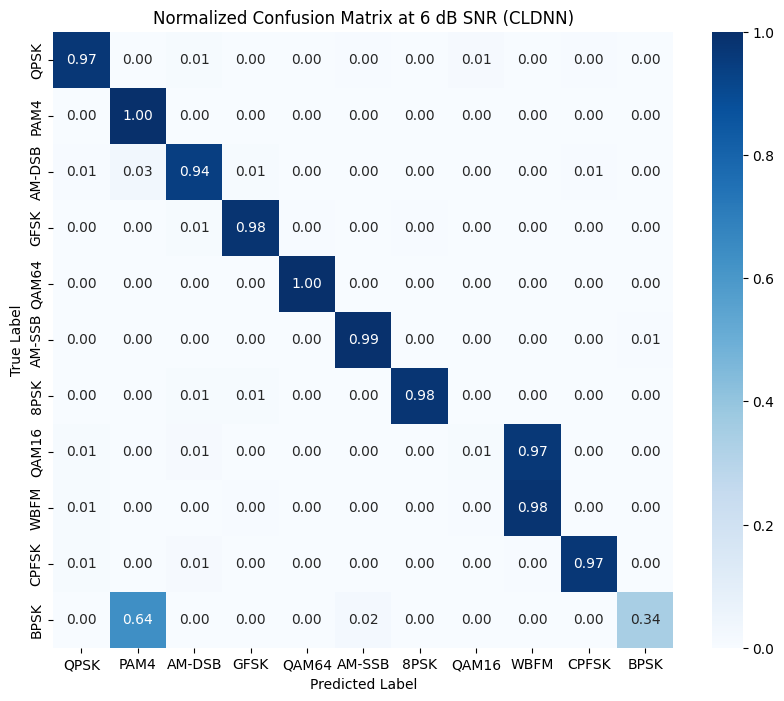

In [ ]:
print("Plotting normalized confusion matrix...")
high_snr_idx = np.where(snrs_test == 6)
X_high_snr = X_test[high_snr_idx]
Y_high_snr = Y_test[high_snr_idx]

# Get predictions
Y_pred = model.predict(X_high_snr)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_high_snr, axis=1)

# --- START OF MODIFICATION ---

# Compute confusion matrix and normalize it by the true labels (rows)
# This shows the proportion of each true class that was predicted as each class
cm = confusion_matrix(Y_true_classes, Y_pred_classes, normalize='true')

# Plot
plt.figure(figsize=(10, 8))

# annot=True displays the values
# fmt='.2f' formats the values as floats with 2 decimal places
# vmin=0.0 and vmax=1.0 lock the color bar to the 0-1 range
sns.heatmap(cm,
            annot=True,
            fmt='.2f',  # <--- CHANGED
            xticklabels=mods,
            yticklabels=mods,
            cmap='Blues',
            vmin=0.0,   # <--- ADDED
            vmax=1.0    # <--- ADDED
           )

plt.title('Normalized Confusion Matrix at 6 dB SNR (CLDNN)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
print(f"Accuracy at 6 dB SNR: {acc_vs_snr[6]*100:.2f}%")

Accuracy at 6 dB SNR: 83.53%


In [ ]:
# Save the model in the standard Keras format
model_filename = 'cldnn_radioml_10a.keras'
model.save(model_filename)

print(f"Model successfully saved as: {model_filename}")

Model successfully saved as: cldnn_radioml_10a.keras


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Analyze High-Weight Features for CLDNN (Conv2D Layer) ---

# 1. Get the weights of the first Conv2D layer
# The name we gave it in the CLDNN build step was 'Conv2D_1'
try:
    # Weights shape: (Kernel_H, Kernel_W, Input_Channels, Filters) -> (2, 8, 1, 32)
    first_layer_weights = model.get_layer('Conv2D_1').get_weights()[0]

    print(f"First Layer Weight Shape: {first_layer_weights.shape}")

    # 2. Calculate the 'Strength' (L1 Norm) of each of the 32 filters
    # We sum the absolute values across height, width, and channels
    filter_strength = np.sum(np.abs(first_layer_weights), axis=(0, 1, 2))

    # 3. Find the indices of the top 3 filters with highest weights
    top_n = 3
    top_filter_indices = np.argsort(filter_strength)[-top_n:][::-1]

    print(f"\nTop {top_n} Strongest Filters: {top_filter_indices}")

    # 4. Plot the weights of these top filters
    plt.figure(figsize=(15, 5))

    for i, filter_idx in enumerate(top_filter_indices):
        plt.subplot(1, top_n, i+1)

        # Get weights for this specific filter.
        # Squeeze to remove the singleton channel dimension -> Shape becomes (2, 8)
        w = np.squeeze(first_layer_weights[:, :, :, filter_idx])

        # Row 0 is I (In-phase), Row 1 is Q (Quadrature)
        plt.plot(w[0, :], 'r-o', label='I (In-phase) Weights')
        plt.plot(w[1, :], 'b-o', label='Q (Quadrature) Weights')

        plt.title(f"Filter #{filter_idx}\nStrength: {filter_strength[filter_idx]:.2f}")
        plt.xlabel("Time Step (Kernel Width)")
        plt.ylabel("Weight Value")
        plt.legend()
        plt.grid(True)

    plt.suptitle("Visualizing the Top Learned Filters in CLDNN (Layer: Conv2D_1)")
    plt.tight_layout()
    plt.show()

except ValueError as e:
    print("Error: Could not find layer 'Conv2D_1'. Are you sure the CLDNN model is currently loaded?")
    print("If you have the MCNN model loaded, you need to reload the CLDNN model first.")

Error: Could not find layer 'Conv2D_1'. Are you sure the CLDNN model is currently loaded?
If you have the MCNN model loaded, you need to reload the CLDNN model first.


# New Section

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    LSTM,
    Dense,
    Dropout,
    Layer
)

import tensorflow.keras.backend as K

In [ ]:
class TemporalAttention(Layer):

    def __init__(self, **kwargs):
        super(TemporalAttention, self).__init__(**kwargs)

    def build(self, input_shape):

        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True
        )

        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

        super(TemporalAttention, self).build(input_shape)

    def call(self, x):

        e = K.tanh(K.dot(x, self.W) + self.b)

        a = K.softmax(e, axis=1)

        output = x * a

        return K.sum(output, axis=1)

In [ ]:
n_classes = Y_train.shape[1]

timesteps = X_train.shape[1]   # 128
features = X_train.shape[2]    # 2

print("Classes:", n_classes)
print("Input shape:", (timesteps, features))

Classes: 11
Input shape: (128, 2)


In [ ]:
inputs = Input(shape=(timesteps, features))

# ---------------- CNN Feature Extractor ----------------

x = Conv1D(
    filters=64,
    kernel_size=5,
    activation='relu',
    padding='same'
)(inputs)

x = BatchNormalization()(x)

x = MaxPooling1D(pool_size=2)(x)


x = Conv1D(
    filters=64,
    kernel_size=5,
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = MaxPooling1D(pool_size=2)(x)

# Output shape ≈ (batch, 32, 64)

# ---------------- LSTM Sequence Modeling ----------------

x = LSTM(
    units=64,
    return_sequences=True
)(x)

x = Dropout(0.5)(x)

x = LSTM(
    units=64,
    return_sequences=True
)(x)

x = Dropout(0.5)(x)

# ---------------- Attention Layer ----------------

x = TemporalAttention()(x)

# ---------------- Dense Classifier ----------------

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

outputs = Dense(
    n_classes,
    activation='softmax'
)(x)

model = Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 64)        │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ (None, 64)             │            96 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,643 (381.42 KB)

 Trainable params: 97,387 (380.42 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
history = model.fit(

    X_train,
    Y_train,

    epochs=50,

    batch_size=1024,

    validation_split=0.1,

    verbose=1
)

Epoch 1/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.2979 - loss: 1.9272 - val_accuracy: 0.1096 - val_loss: 3.7732
Epoch 2/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.4911 - loss: 1.2894 - val_accuracy: 0.3770 - val_loss: 1.7062
Epoch 3/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.5083 - loss: 1.2422 - val_accuracy: 0.5059 - val_loss: 1.2400
Epoch 4/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.5178 - loss: 1.2262 - val_accuracy: 0.5332 - val_loss: 1.1968
Epoch 5/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.5318 - loss: 1.1974 - val_accuracy: 0.5385 - val_loss: 1.1891
Epoch 6/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.5397 - loss: 1.1830 - val_accuracy: 0.5415 - val_loss: 1.1783
Epoch 7/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.5451 - loss: 1.1698 - val_accuracy: 0.5418 - val_loss: 1.1671
Epoch 8/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.5569 - loss: 1.1492 - val_ac

In [ ]:
predictions = model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(Y_test, axis=1)

1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


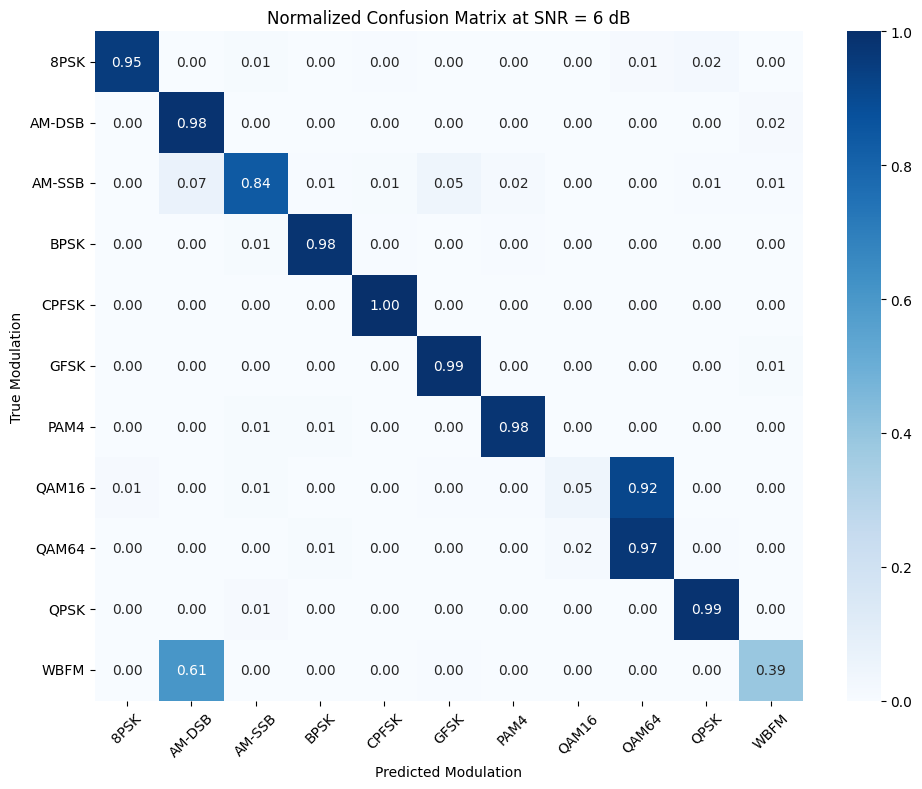

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select samples with SNR = 6 dB
indices_6db = np.where(snrs_test == 6)[0]

# Filter the test data
X_test_6db = X_test[indices_6db]
Y_test_6db = Y_test[indices_6db]

# Predict
predictions_6db = model.predict(X_test_6db)

pred_classes_6db = np.argmax(predictions_6db, axis=1)
true_classes_6db = np.argmax(Y_test_6db, axis=1)

# Confusion matrix
cm_6db = confusion_matrix(true_classes_6db, pred_classes_6db)

# Normalize (0–1)
cm_6db_norm = cm_6db.astype('float') / cm_6db.sum(axis=1)[:, np.newaxis]

# Get modulation labels
labels = encoder.classes_

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    cm_6db_norm,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Normalized Confusion Matrix at SNR = 6 dB")

plt.xlabel("Predicted Modulation")
plt.ylabel("True Modulation")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()